# CELL 1 — ENVIRONMENT GPU CHECK

In [1]:
# ============================================================
# PEMERIKSAAN ENVIRONMENT GPU
# ============================================================

import torch
import platform


print("="*70)
print("ENVIRONMENT CHECK")
print("="*70)


print(
    "Python:",
    platform.python_version()
)


print(
    "PyTorch:",
    torch.__version__
)


print(
    "CUDA tersedia:",
    torch.cuda.is_available()
)


if not torch.cuda.is_available():

    raise RuntimeError(
        "GPU tidak tersedia. Aktifkan Runtime GPU terlebih dahulu."
    )


device = torch.device(
    "cuda"
)


print(
    "GPU:",
    torch.cuda.get_device_name(0)
)


print(
    "VRAM GB:",
    round(
        torch.cuda.get_device_properties(0).total_memory / 1024**3,
        2
    )
)


print(
    "✅ GPU siap digunakan"
)

ENVIRONMENT CHECK
Python: 3.13.15
PyTorch: 2.11.0+cu128
CUDA tersedia: True
GPU: Tesla T4
VRAM GB: 14.56
✅ GPU siap digunakan


# CELL 2 — MOUNT GOOGLE DRIVE

In [2]:
# ============================================================
# MOUNT GOOGLE DRIVE
# ============================================================

from google.colab import drive


drive.mount(
    "/content/drive"
)


print(
    "✅ Google Drive berhasil terhubung"
)

Mounted at /content/drive
✅ Google Drive berhasil terhubung


# CELL 3 — CLONE / UPDATE REPOSITORY

In [3]:
# ============================================================
# UPDATE REPOSITORY GITHUB
# ============================================================

import os
import subprocess


REPO_DIR = (
    "/content/label-noise-thesis"
)


if os.path.exists(REPO_DIR):

    print(
        "Repository sudah ada."
    )

    subprocess.run(
        [
            "git",
            "-C",
            REPO_DIR,
            "pull"
        ],
        check=True
    )

else:

    subprocess.run(
        [
            "git",
            "clone",
            "https://github.com/luthfiaw13/label-noise-thesis.git",
            REPO_DIR
        ],
        check=True
    )


print(
    "✅ Repository siap"
)

✅ Repository siap


# CELL 4 — DEFINISI PATH

In [4]:
# ============================================================
# DEFINISI PATH PROYEK
# ============================================================

from pathlib import Path


PROJECT_DIR = Path(
    "/content/label-noise-thesis"
)


DRIVE_DIR = Path(
    "/content/drive/MyDrive/skripsi_label_noise"
)


OUTPUT_DIR = DRIVE_DIR / "outputs"


PHASE_NAME = "smoke test validation"


DIR_CHECKPOINT = (
    OUTPUT_DIR /
    "checkpoints" /
    PHASE_NAME
)


DIR_METRIC = (
    OUTPUT_DIR /
    "metrics" /
    PHASE_NAME
)


DIR_FIGURE = (
    OUTPUT_DIR /
    "figures" /
    PHASE_NAME
)


DIR_METADATA = (
    OUTPUT_DIR /
    "run_metadata" /
    PHASE_NAME
)


for folder in [
    DIR_CHECKPOINT,
    DIR_METRIC,
    DIR_FIGURE,
    DIR_METADATA,
]:

    folder.mkdir(
        parents=True,
        exist_ok=True
    )


print(
    "✅ Struktur output siap"
)

✅ Struktur output siap


# CELL 5 — BERSIHKAN OUTPUT LAMA

In [5]:
# ============================================================
# MEMBERSIHKAN OUTPUT LAMA
# ============================================================

import shutil


for folder in [
    DIR_CHECKPOINT,
    DIR_METRIC,
    DIR_FIGURE,
    DIR_METADATA,
]:

    if folder.exists():

        shutil.rmtree(
            folder
        )


    folder.mkdir(
        parents=True,
        exist_ok=True
    )


print(
    "✅ Output lama berhasil dibersihkan"
)

✅ Output lama berhasil dibersihkan


# CELL 6 — Perbaiki checkpoint.py menjadi versi final

In [6]:
# ============================================================
# CELL 6 — CHECKPOINT MODULE VERSI FINAL
# ============================================================

from pathlib import Path
import py_compile


CHECKPOINT_FILE = (
    PROJECT_DIR
    / "src"
    / "training"
    / "checkpoint.py"
)


kode_checkpoint_final = r'''
"""
Sistem checkpoint training untuk eksperimen skripsi.

Checkpoint menyimpan:
- model state;
- optimizer state;
- scheduler state;
- AMP GradScaler state;
- global optimizer step;
- konfigurasi run;
- RNG Python;
- RNG NumPy;
- RNG PyTorch CPU;
- RNG CUDA;
- DataLoader generator state.

Checkpoint selalu dimuat terlebih dahulu ke CPU agar state RNG
tidak ikut dipindahkan ke CUDA secara tidak sengaja.
"""

from pathlib import Path

import os
import random

import numpy as np
import torch


def simpan_checkpoint(
    lokasi,
    model,
    optimizer,
    scheduler,
    scaler,
    global_step,
    generator_train,
    config,
):
    """
    Menyimpan checkpoint secara atomic.

    File terlebih dahulu ditulis sebagai file sementara,
    kemudian dipindahkan ke nama final.
    """

    lokasi = Path(lokasi)

    lokasi.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    checkpoint = {

        "model_state_dict":
            model.state_dict(),

        "optimizer_state_dict":
            optimizer.state_dict(),

        "scheduler_state_dict":
            (
                scheduler.state_dict()
                if scheduler is not None
                else None
            ),

        "scaler_state_dict":
            (
                scaler.state_dict()
                if scaler is not None
                else None
            ),

        "global_step":
            int(global_step),

        "config":
            config,

        # ----------------------------------------------------
        # RNG state
        # ----------------------------------------------------

        "python_rng_state":
            random.getstate(),

        "numpy_rng_state":
            np.random.get_state(),

        "torch_rng_state":
            torch.get_rng_state(),

        "cuda_rng_state":
            (
                torch.cuda.get_rng_state_all()
                if torch.cuda.is_available()
                else None
            ),

        "generator_train_state":
            (
                generator_train.get_state()
                if generator_train is not None
                else None
            ),
    }

    lokasi_temp = lokasi.with_suffix(
        lokasi.suffix + ".tmp"
    )

    torch.save(
        checkpoint,
        lokasi_temp
    )

    os.replace(
        lokasi_temp,
        lokasi
    )


def _pindahkan_optimizer_ke_device(
    optimizer,
    device,
):
    """
    Memastikan seluruh tensor internal optimizer berada
    pada device yang sama dengan model.
    """

    for state in optimizer.state.values():

        for key, value in state.items():

            if isinstance(
                value,
                torch.Tensor
            ):
                state[key] = value.to(
                    device
                )


def muat_checkpoint(
    lokasi,
    model,
    optimizer,
    scheduler,
    scaler,
    generator_train,
    device,
):
    """
    Memuat checkpoint training secara aman.

    Strategi:
    1. Checkpoint selalu dibaca ke CPU.
    2. Model state dimuat ke model yang sudah berada di device.
    3. Optimizer state dimuat kemudian dipindahkan ke device.
    4. RNG state tetap dipulihkan sebagai CPU ByteTensor.
    5. CUDA RNG dipulihkan secara eksplisit jika tersedia.

    weights_only=False digunakan karena checkpoint milik sendiri
    berisi state Python dan NumPy selain tensor.
    """

    lokasi = Path(lokasi)

    if not lokasi.exists():

        raise FileNotFoundError(
            f"Checkpoint tidak ditemukan: {lokasi}"
        )

    # --------------------------------------------------------
    # PENTING:
    # Selalu load ke CPU terlebih dahulu.
    # Jangan map seluruh checkpoint langsung ke CUDA karena
    # RNG/DataLoader generator state harus tetap CPU tensor.
    # --------------------------------------------------------

    checkpoint = torch.load(
        lokasi,
        map_location="cpu",
        weights_only=False
    )

    required_keys = {
        "model_state_dict",
        "optimizer_state_dict",
        "scheduler_state_dict",
        "scaler_state_dict",
        "global_step",
        "config",
        "python_rng_state",
        "numpy_rng_state",
        "torch_rng_state",
        "cuda_rng_state",
        "generator_train_state",
    }

    missing_keys = (
        required_keys
        -
        set(checkpoint.keys())
    )

    if missing_keys:

        raise RuntimeError(
            "Checkpoint tidak lengkap. Key hilang: "
            f"{sorted(missing_keys)}"
        )

    # --------------------------------------------------------
    # Restore model.
    # --------------------------------------------------------

    model.load_state_dict(
        checkpoint[
            "model_state_dict"
        ]
    )

    # --------------------------------------------------------
    # Restore optimizer.
    # --------------------------------------------------------

    optimizer.load_state_dict(
        checkpoint[
            "optimizer_state_dict"
        ]
    )

    _pindahkan_optimizer_ke_device(
        optimizer,
        device
    )

    # --------------------------------------------------------
    # Restore scheduler.
    # --------------------------------------------------------

    if (
        scheduler is not None
        and
        checkpoint[
            "scheduler_state_dict"
        ]
        is not None
    ):

        scheduler.load_state_dict(
            checkpoint[
                "scheduler_state_dict"
            ]
        )

    # --------------------------------------------------------
    # Restore AMP scaler.
    # --------------------------------------------------------

    if (
        scaler is not None
        and
        checkpoint[
            "scaler_state_dict"
        ]
        is not None
    ):

        scaler.load_state_dict(
            checkpoint[
                "scaler_state_dict"
            ]
        )

    # --------------------------------------------------------
    # Restore RNG Python.
    # --------------------------------------------------------

    random.setstate(
        checkpoint[
            "python_rng_state"
        ]
    )

    # --------------------------------------------------------
    # Restore RNG NumPy.
    # --------------------------------------------------------

    np.random.set_state(
        checkpoint[
            "numpy_rng_state"
        ]
    )

    # --------------------------------------------------------
    # Restore RNG PyTorch CPU.
    # torch.set_rng_state membutuhkan CPU ByteTensor.
    # --------------------------------------------------------

    torch_rng_state = checkpoint[
        "torch_rng_state"
    ]

    if not isinstance(
        torch_rng_state,
        torch.Tensor
    ):

        torch_rng_state = torch.tensor(
            torch_rng_state,
            dtype=torch.uint8
        )

    torch_rng_state = (
        torch_rng_state
        .detach()
        .cpu()
        .to(dtype=torch.uint8)
        .contiguous()
    )

    torch.set_rng_state(
        torch_rng_state
    )

    # --------------------------------------------------------
    # Restore CUDA RNG.
    # CUDA RNG state juga direpresentasikan sebagai ByteTensor.
    # --------------------------------------------------------

    cuda_rng_state = checkpoint.get(
        "cuda_rng_state"
    )

    if (
        torch.cuda.is_available()
        and
        cuda_rng_state is not None
    ):

        jumlah_gpu = torch.cuda.device_count()

        if len(cuda_rng_state) != jumlah_gpu:

            raise RuntimeError(
                "Jumlah CUDA RNG state pada checkpoint "
                f"({len(cuda_rng_state)}) berbeda dengan "
                f"jumlah GPU runtime ({jumlah_gpu})."
            )

        cuda_states_final = []

        for state in cuda_rng_state:

            if not isinstance(
                state,
                torch.Tensor
            ):

                state = torch.tensor(
                    state,
                    dtype=torch.uint8
                )

            state = (
                state
                .detach()
                .cpu()
                .to(dtype=torch.uint8)
                .contiguous()
            )

            cuda_states_final.append(
                state
            )

        torch.cuda.set_rng_state_all(
            cuda_states_final
        )

    # --------------------------------------------------------
    # Restore DataLoader generator.
    # torch.Generator CPU membutuhkan CPU ByteTensor.
    # --------------------------------------------------------

    generator_state = checkpoint.get(
        "generator_train_state"
    )

    if (
        generator_train is not None
        and
        generator_state is not None
    ):

        if not isinstance(
            generator_state,
            torch.Tensor
        ):

            generator_state = torch.tensor(
                generator_state,
                dtype=torch.uint8
            )

        generator_state = (
            generator_state
            .detach()
            .cpu()
            .to(dtype=torch.uint8)
            .contiguous()
        )

        generator_train.set_state(
            generator_state
        )

    return {

        "global_step":
            int(
                checkpoint[
                    "global_step"
                ]
            ),

        "config":
            checkpoint[
                "config"
            ],
    }
'''


CHECKPOINT_FILE.write_text(
    kode_checkpoint_final,
    encoding="utf-8"
)


# ------------------------------------------------------------
# Syntax check WAJIB sebelum import.
# ------------------------------------------------------------

py_compile.compile(
    str(CHECKPOINT_FILE),
    doraise=True
)


print("=" * 70)
print("CHECKPOINT MODULE FINAL")
print("=" * 70)

print(
    "Lokasi:",
    CHECKPOINT_FILE
)

print(
    "✅ File checkpoint.py berhasil ditulis ulang."
)

print(
    "✅ Syntax checkpoint.py valid."
)

CHECKPOINT MODULE FINAL
Lokasi: /content/label-noise-thesis/src/training/checkpoint.py
✅ File checkpoint.py berhasil ditulis ulang.
✅ Syntax checkpoint.py valid.


# CELL 7 — Import modul secara bersih

In [7]:
# ============================================================
# CELL 7 — IMPORT MODUL PROYEK SECARA BERSIH
# ============================================================

import sys
import importlib


# ------------------------------------------------------------
# Pastikan repository berada paling depan di sys.path.
# ------------------------------------------------------------

repo_str = str(
    PROJECT_DIR
)

if repo_str in sys.path:
    sys.path.remove(
        repo_str
    )

sys.path.insert(
    0,
    repo_str
)


# ------------------------------------------------------------
# Hapus seluruh cache modul src agar tidak menggunakan
# kode versi lama dari runtime.
# ------------------------------------------------------------

for nama_modul in list(
    sys.modules.keys()
):

    if (
        nama_modul == "src"
        or
        nama_modul.startswith("src.")
    ):

        del sys.modules[
            nama_modul
        ]


importlib.invalidate_caches()


# ------------------------------------------------------------
# Import source proyek.
# ------------------------------------------------------------

from src.models.resnet import (
    bangun_resnet_cifar
)

from src.data.cifar import (
    CIFAR10Berindeks,
    buat_transformasi_cifar10,
    CIFAR10_MEAN,
    CIFAR10_STD,
)

from src.data.subsets import (
    buat_split_smoke
)

from src.training.seed import (
    atur_seed,
    seed_worker,
    buat_generator,
)

from src.training.engine import (
    buat_scheduler_warmup_cosine,
    latih_hingga_step,
)

from src.training.checkpoint import (
    simpan_checkpoint,
    muat_checkpoint,
)

from src.evaluation.classification import (
    evaluasi_klasifikasi
)


print("=" * 70)
print("IMPORT MODUL")
print("=" * 70)

print("✅ Model ResNet")
print("✅ Dataset CIFAR")
print("✅ Smoke split")
print("✅ Seed dan reproducibility")
print("✅ Fixed-step training engine")
print("✅ Checkpoint final")
print("✅ Evaluation")

print()
print(
    "✅ SELURUH MODUL BERHASIL DI-IMPORT."
)

IMPORT MODUL
✅ Model ResNet
✅ Dataset CIFAR
✅ Smoke split
✅ Seed dan reproducibility
✅ Fixed-step training engine
✅ Checkpoint final
✅ Evaluation

✅ SELURUH MODUL BERHASIL DI-IMPORT.


# CELL 8 — Seed dan dataset CIFAR-10

In [8]:
# ============================================================
# CELL 8 — SEED DAN LOAD CIFAR-10 TRAINING
# ============================================================

import numpy as np

from torchvision.datasets import CIFAR10


TRAINING_SEED = 17
SUBSET_SEED = 314159


# ------------------------------------------------------------
# Atur seluruh sumber randomness.
# ------------------------------------------------------------

atur_seed(
    TRAINING_SEED,
    deterministik=True
)


DATA_ROOT = Path(
    "/content/label_noise_data/cifar"
)

DATA_ROOT.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# HANYA load CIFAR-10 training set.
# Official test tidak digunakan pada smoke test.
# ------------------------------------------------------------

cifar_train_raw = CIFAR10(
    root=str(DATA_ROOT),
    train=True,
    download=True
)


label_bersih = np.asarray(
    cifar_train_raw.targets,
    dtype=np.int64
)


assert len(
    cifar_train_raw
) == 50_000

assert label_bersih.shape == (
    50_000,
)


print("=" * 70)
print("DATASET SMOKE TEST")
print("=" * 70)

print(
    "Jumlah training CIFAR-10 :",
    f"{len(cifar_train_raw):,}"
)

print(
    "Jumlah kelas             :",
    len(cifar_train_raw.classes)
)

print(
    "Official test set        : TIDAK DIMUAT"
)

print(
    "Training seed            :",
    TRAINING_SEED
)

print(
    "Subset seed              :",
    SUBSET_SEED
)

print()
print(
    "✅ Dataset training siap dan test-set lock dipatuhi."
)

100%|██████████| 170M/170M [46:06<00:00, 61.6kB/s]


DATASET SMOKE TEST
Jumlah training CIFAR-10 : 50,000
Jumlah kelas             : 10
Official test set        : TIDAK DIMUAT
Training seed            : 17
Subset seed              : 314159

✅ Dataset training siap dan test-set lock dipatuhi.


# CELL 9 — Gunakan split smoke yang sudah dibekukan

In [10]:
# ============================================================
# CELL 9 — LOAD / BUAT SPLIT SMOKE
# ============================================================

import pandas as pd
import numpy as np

SPLIT_DIR = (
    DRIVE_DIR
    / "artifacts"
    / "splits"
)

SPLIT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


PATH_ALL = (
    SPLIT_DIR
    / "smoke_c10_all_indices.npy"
)

PATH_TRAIN = (
    SPLIT_DIR
    / "smoke_c10_train_indices.npy"
)

PATH_VAL = (
    SPLIT_DIR
    / "smoke_c10_val_indices.npy"
)


if (
    PATH_ALL.exists()
    and
    PATH_TRAIN.exists()
    and
    PATH_VAL.exists()
):

    print(
        "Split smoke ditemukan."
    )

    print(
        "Menggunakan kembali split yang sudah dibekukan."
    )

    indeks_smoke = np.load(
        PATH_ALL
    )

    indeks_train = np.load(
        PATH_TRAIN
    )

    indeks_val = np.load(
        PATH_VAL
    )

else:

    print(
        "Split smoke belum tersedia."
    )

    print(
        "Membuat split stratified satu kali."
    )

    (
        indeks_smoke,
        indeks_train,
        indeks_val
    ) = buat_split_smoke(
        labels=label_bersih,
        jumlah_subset=2000,
        proporsi_validasi=0.20,
        seed=SUBSET_SEED,
    )

    np.save(
        PATH_ALL,
        indeks_smoke
    )

    np.save(
        PATH_TRAIN,
        indeks_train
    )

    np.save(
        PATH_VAL,
        indeks_val
    )


# ------------------------------------------------------------
# Hard validation.
# ------------------------------------------------------------

assert len(
    indeks_smoke
) == 2000

assert len(
    indeks_train
) == 1600

assert len(
    indeks_val
) == 400


overlap = np.intersect1d(
    indeks_train,
    indeks_val
)

assert len(
    overlap
) == 0


# ------------------------------------------------------------
# Distribusi kelas.
# ------------------------------------------------------------

records_distribusi = []


for kelas_id in range(10):

    jumlah_train = int(
        np.sum(
            label_bersih[
                indeks_train
            ]
            ==
            kelas_id
        )
    )

    jumlah_val = int(
        np.sum(
            label_bersih[
                indeks_val
            ]
            ==
            kelas_id
        )
    )

    records_distribusi.append(
        {
            "kelas_id":
                kelas_id,

            "nama_kelas":
                cifar_train_raw.classes[
                    kelas_id
                ],

            "training":
                jumlah_train,

            "validation":
                jumlah_val,
        }
    )


df_distribusi = pd.DataFrame(
    records_distribusi
)


assert np.all(
    df_distribusi[
        "training"
    ].values == 160
)

assert np.all(
    df_distribusi[
        "validation"
    ].values == 40
)


print()
print("=" * 70)
print("SPLIT SMOKE FINAL")
print("=" * 70)

print(
    "Total subset :",
    len(indeks_smoke)
)

print(
    "Training     :",
    len(indeks_train)
)

print(
    "Validation   :",
    len(indeks_val)
)

print(
    "Overlap      :",
    len(overlap)
)

print()

display(
    df_distribusi
)

print()
print(
    "✅ Split smoke valid, stratified, dan bebas overlap."
)

Split smoke ditemukan.
Menggunakan kembali split yang sudah dibekukan.

SPLIT SMOKE FINAL
Total subset : 2000
Training     : 1600
Validation   : 400
Overlap      : 0



,kelas_id,nama_kelas,training,validation
0,0,airplane,160,40
1,1,automobile,160,40
2,2,bird,160,40
3,3,cat,160,40
4,4,deer,160,40
5,5,dog,160,40
6,6,frog,160,40
7,7,horse,160,40
8,8,ship,160,40
9,9,truck,160,40



✅ Split smoke valid, stratified, dan bebas overlap.


# CELL 10 — Dataset + DataLoader + preflight

In [11]:
# ============================================================
# CELL 10 — DATASET DAN DATALOADER
# ============================================================

BATCH_SIZE = 256
NUM_WORKERS = 2


# ------------------------------------------------------------
# Transformasi.
# ------------------------------------------------------------

transform_train = (
    buat_transformasi_cifar10(
        "train"
    )
)

transform_val = (
    buat_transformasi_cifar10(
        "eval"
    )
)


# ------------------------------------------------------------
# Dataset wrapper mempertahankan original CIFAR index.
# ------------------------------------------------------------

dataset_train = CIFAR10Berindeks(
    root=str(DATA_ROOT),
    indeks=indeks_train,
    transform=transform_train,
    labels_override=None,
    download=False,
)

dataset_val = CIFAR10Berindeks(
    root=str(DATA_ROOT),
    indeks=indeks_val,
    transform=transform_val,
    labels_override=None,
    download=False,
)


# ------------------------------------------------------------
# Generator DataLoader selalu CPU generator.
# ------------------------------------------------------------

generator_train = buat_generator(
    TRAINING_SEED
)

generator_val = buat_generator(
    TRAINING_SEED + 1000
)


train_loader = torch.utils.data.DataLoader(
    dataset_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    worker_init_fn=seed_worker,
    generator=generator_train,
    persistent_workers=False,
)

val_loader = torch.utils.data.DataLoader(
    dataset_val,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    worker_init_fn=seed_worker,
    generator=generator_val,
    persistent_workers=False,
)


# ------------------------------------------------------------
# Preflight batch.
# ------------------------------------------------------------

batch_gambar, batch_label, batch_indeks = next(
    iter(
        train_loader
    )
)


assert batch_gambar.shape == (
    BATCH_SIZE,
    3,
    32,
    32
)

assert batch_label.shape == (
    BATCH_SIZE,
)

assert batch_indeks.shape == (
    BATCH_SIZE,
)

assert torch.isfinite(
    batch_gambar
).all()


print("=" * 70)
print("DATALOADER + PREFLIGHT")
print("=" * 70)

print(
    "Batch size         :",
    BATCH_SIZE
)

print(
    "Jumlah batch train :",
    len(train_loader)
)

print(
    "Jumlah batch val   :",
    len(val_loader)
)

print(
    "Jumlah worker      :",
    NUM_WORKERS
)

print(
    "Generator train    :",
    generator_train.device
)

print()

print(
    "Bentuk gambar      :",
    tuple(
        batch_gambar.shape
    )
)

print(
    "Bentuk label       :",
    tuple(
        batch_label.shape
    )
)

print(
    "Bentuk indeks      :",
    tuple(
        batch_indeks.shape
    )
)

print()
print(
    "✅ DataLoader dan preflight batch valid."
)

DATALOADER + PREFLIGHT
Batch size         : 256
Jumlah batch train : 7
Jumlah batch val   : 2
Jumlah worker      : 2
Generator train    : cpu

Bentuk gambar      : (256, 3, 32, 32)
Bentuk label       : (256,)
Bentuk indeks      : (256,)

✅ DataLoader dan preflight batch valid.


# CELL 11 — Visualisasi augmentation versi final

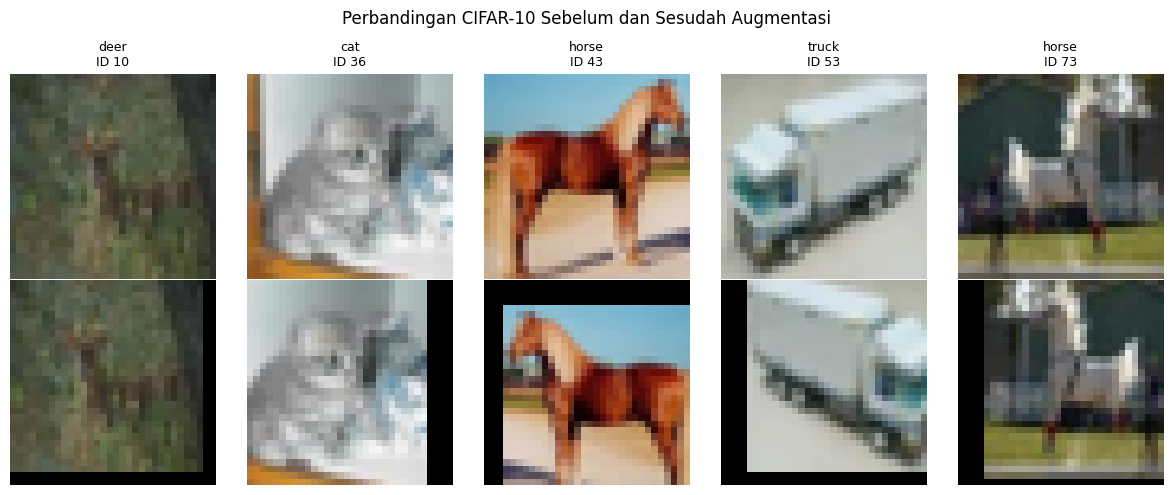

✅ Visualisasi augmentation tersimpan:
/content/drive/MyDrive/skripsi_label_noise/outputs/figures/smoke test validation/smoke_augmentation_comparison.png


In [12]:
# ============================================================
# CELL 11 — VISUALISASI AUGMENTATION
# ============================================================

from PIL import Image

import matplotlib.pyplot as plt


mean_tensor = torch.tensor(
    CIFAR10_MEAN
).view(
    3,
    1,
    1
)

std_tensor = torch.tensor(
    CIFAR10_STD
).view(
    3,
    1,
    1
)


jumlah_contoh = 5

contoh_indeks = indeks_train[
    :jumlah_contoh
]


fig, axes = plt.subplots(
    2,
    jumlah_contoh,
    figsize=(12, 5)
)


for kolom, original_id in enumerate(
    contoh_indeks
):

    original_id = int(
        original_id
    )

    gambar_asli = (
        cifar_train_raw.data[
            original_id
        ]
    )

    label_asli = int(
        cifar_train_raw.targets[
            original_id
        ]
    )

    # --------------------------------------------------------
    # Baris atas: gambar CIFAR asli.
    # --------------------------------------------------------

    axes[
        0,
        kolom
    ].imshow(
        gambar_asli,
        interpolation="nearest"
    )

    axes[
        0,
        kolom
    ].set_title(
        f"{cifar_train_raw.classes[label_asli]}\n"
        f"ID {original_id}",
        fontsize=9
    )

    axes[
        0,
        kolom
    ].axis(
        "off"
    )

    # --------------------------------------------------------
    # Baris bawah: hasil augmentation.
    # --------------------------------------------------------

    gambar_aug = transform_train(
        Image.fromarray(
            gambar_asli
        )
    )

    gambar_tampil = (
        gambar_aug
        *
        std_tensor
        +
        mean_tensor
    )

    gambar_tampil = (
        gambar_tampil
        .clamp(
            0,
            1
        )
        .permute(
            1,
            2,
            0
        )
        .numpy()
    )

    axes[
        1,
        kolom
    ].imshow(
        gambar_tampil,
        interpolation="nearest"
    )

    axes[
        1,
        kolom
    ].axis(
        "off"
    )


axes[
    0,
    0
].set_ylabel(
    "Citra Asli",
    fontsize=11
)

axes[
    1,
    0
].set_ylabel(
    "Setelah\nAugmentasi",
    fontsize=11
)


plt.suptitle(
    "Perbandingan CIFAR-10 Sebelum dan Sesudah Augmentasi"
)

plt.tight_layout()


PATH_AUG = (
    DIR_FIGURE
    / "smoke_augmentation_comparison.png"
)


plt.savefig(
    PATH_AUG,
    dpi=250,
    bbox_inches="tight"
)

plt.show()


print(
    "✅ Visualisasi augmentation tersimpan:"
)

print(
    PATH_AUG
)

# CELL 12 — Konfigurasi + model + optimizer + scheduler + AMP

In [13]:
# ============================================================
# CELL 12 — TRAINING COMPONENT
# ============================================================

import time
import json
import subprocess


JUMLAH_BATCH_PER_PUTARAN = len(
    train_loader
)


# 4 putaran penuh sebelum checkpoint.
STEP_CHECKPOINT = (
    4
    *
    JUMLAH_BATCH_PER_PUTARAN
)


# Total 8 putaran penuh.
TOTAL_STEP = (
    8
    *
    JUMLAH_BATCH_PER_PUTARAN
)


# Satu putaran digunakan sebagai warmup.
WARMUP_STEPS = (
    JUMLAH_BATCH_PER_PUTARAN
)


SMOKE_CONFIG = {

    "fase":
        "Smoke Test Validation",

    "dataset":
        "CIFAR-10 clean",

    "model":
        "resnet18",

    "subset_total":
        2000,

    "training_samples":
        1600,

    "validation_samples":
        400,

    "training_seed":
        TRAINING_SEED,

    "subset_seed":
        SUBSET_SEED,

    "batch_size":
        BATCH_SIZE,

    "num_workers":
        NUM_WORKERS,

    "optimizer":
        "SGD",

    "learning_rate":
        0.1,

    "momentum":
        0.9,

    "weight_decay":
        5e-4,

    "loss":
        "CrossEntropyLoss",

    "scheduler":
        "linear warmup + cosine decay",

    "warmup_steps":
        WARMUP_STEPS,

    "checkpoint_step":
        STEP_CHECKPOINT,

    "total_steps":
        TOTAL_STEP,

    "amp":
        True,

    "device":
        str(device),

    "gpu":
        torch.cuda.get_device_name(0),

    "official_test_used":
        False,

    "note":
        (
            "Smoke test teknis. "
            "Bukan konfigurasi performa final skripsi."
        ),
}


# ------------------------------------------------------------
# Reset seed sebelum model dibuat.
# ------------------------------------------------------------

atur_seed(
    TRAINING_SEED,
    deterministik=True
)


model = bangun_resnet_cifar(
    nama_model="resnet18",
    jumlah_kelas=10
).to(
    device
)


criterion = torch.nn.CrossEntropyLoss()


optimizer = torch.optim.SGD(
    model.parameters(),
    lr=SMOKE_CONFIG[
        "learning_rate"
    ],
    momentum=SMOKE_CONFIG[
        "momentum"
    ],
    weight_decay=SMOKE_CONFIG[
        "weight_decay"
    ],
)


scheduler = buat_scheduler_warmup_cosine(
    optimizer=optimizer,
    total_steps=TOTAL_STEP,
    warmup_steps=WARMUP_STEPS,
)


AMP_AKTIF = (
    device.type == "cuda"
)


if not AMP_AKTIF:

    raise RuntimeError(
        "AMP GPU tidak aktif. "
        "Smoke test final tidak boleh dilanjutkan."
    )


scaler = torch.amp.GradScaler(
    "cuda",
    enabled=True
)


# ------------------------------------------------------------
# Sanity forward GPU.
# ------------------------------------------------------------

batch_uji = batch_gambar[
    :4
].to(
    device,
    non_blocking=True
)


model.eval()


with torch.inference_mode():

    with torch.autocast(
        device_type="cuda",
        dtype=torch.float16,
        enabled=True
    ):

        output_uji = model(
            batch_uji
        )


assert output_uji.shape == (
    4,
    10
)


# ------------------------------------------------------------
# Git commit yang benar-benar sedang digunakan.
# ------------------------------------------------------------

GIT_COMMIT = subprocess.run(
    [
        "git",
        "-C",
        str(PROJECT_DIR),
        "rev-parse",
        "HEAD"
    ],
    capture_output=True,
    text=True,
    check=True
).stdout.strip()


print("=" * 70)
print("KONFIGURASI SMOKE GPU FINAL")
print("=" * 70)

print(
    "GPU                  :",
    torch.cuda.get_device_name(0)
)

print(
    "AMP aktif            :",
    AMP_AKTIF
)

print(
    "Model                : ResNet18"
)

print(
    "Batch size           :",
    BATCH_SIZE
)

print(
    "Batch/putaran        :",
    JUMLAH_BATCH_PER_PUTARAN
)

print(
    "Checkpoint step      :",
    STEP_CHECKPOINT
)

print(
    "Total optimizer step :",
    TOTAL_STEP
)

print(
    "Warmup step          :",
    WARMUP_STEPS
)

print(
    "Git commit           :",
    GIT_COMMIT
)

print()
print(
    "✅ Training component GPU siap."
)

KONFIGURASI SMOKE GPU FINAL
GPU                  : Tesla T4
AMP aktif            : True
Model                : ResNet18
Batch size           : 256
Batch/putaran        : 7
Checkpoint step      : 28
Total optimizer step : 56
Warmup step          : 7
Git commit           : 52bee590860445857c7decfcc867476be5ea57cd

✅ Training component GPU siap.


# CELL 13 — Training Tahap 1

In [14]:
# ============================================================
# CELL 13 — TRAINING TAHAP 1
# ============================================================

torch.cuda.empty_cache()

torch.cuda.reset_peak_memory_stats()


WAKTU_MULAI_TOTAL = (
    time.perf_counter()
)


print("=" * 70)
print("TRAINING SMOKE GPU — TAHAP 1")
print("=" * 70)


step_sekarang, riwayat_1 = (
    latih_hingga_step(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        scheduler=scheduler,
        criterion=criterion,
        device=device,
        scaler=scaler,
        global_step_awal=0,
        global_step_target=STEP_CHECKPOINT,
        gunakan_amp=True,
    )
)


assert (
    step_sekarang
    ==
    STEP_CHECKPOINT
)


print()
print(
    "✅ Training Tahap 1 selesai pada step:",
    step_sekarang
)

TRAINING SMOKE GPU — TAHAP 1
Step   7/28 | Train Loss: 2.3378 | Train Acc: 14.75% | Val Loss: 21.2926 | Val Acc: 10.50% | LR: 0.100000
Step  14/28 | Train Loss: 3.0908 | Train Acc: 15.75% | Val Loss: 140.8691 | Val Acc: 8.25% | LR: 0.095048
Step  21/28 | Train Loss: 2.6493 | Train Acc: 19.25% | Val Loss: 220.6508 | Val Acc: 10.50% | LR: 0.081174
Step  28/28 | Train Loss: 2.2235 | Train Acc: 23.69% | Val Loss: 3.4287 | Val Acc: 17.00% | LR: 0.061126

✅ Training Tahap 1 selesai pada step: 28


# CELL 14 — Simpan checkpoint GPU + integrity check

In [15]:
# ============================================================
# CELL 14 — SIMPAN DAN VALIDASI CHECKPOINT GPU
# ============================================================

import shutil
import hashlib


LOCAL_CHECKPOINT = Path(
    "/content/"
    "smoke_gpu_step28.pt"
)


DRIVE_CHECKPOINT = (
    DIR_CHECKPOINT
    / "smoke_resnet18_gpu_step28.pt"
)


# ------------------------------------------------------------
# Simpan dahulu di storage lokal Colab.
# ------------------------------------------------------------

simpan_checkpoint(
    lokasi=LOCAL_CHECKPOINT,
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    scaler=scaler,
    global_step=step_sekarang,
    generator_train=generator_train,
    config=SMOKE_CONFIG,
)


# ------------------------------------------------------------
# Salin checkpoint penting ke Drive.
# ------------------------------------------------------------

shutil.copy2(
    LOCAL_CHECKPOINT,
    DRIVE_CHECKPOINT
)


def hitung_sha256(
    path
):

    hasher = hashlib.sha256()

    with open(
        path,
        "rb"
    ) as file:

        while True:

            chunk = file.read(
                1024 * 1024
            )

            if not chunk:
                break

            hasher.update(
                chunk
            )

    return hasher.hexdigest()


hash_lokal = hitung_sha256(
    LOCAL_CHECKPOINT
)

hash_drive = hitung_sha256(
    DRIVE_CHECKPOINT
)


assert (
    hash_lokal
    ==
    hash_drive
)


# ------------------------------------------------------------
# Validasi isi checkpoint secara langsung di CPU.
# ------------------------------------------------------------

checkpoint_uji = torch.load(
    DRIVE_CHECKPOINT,
    map_location="cpu",
    weights_only=False
)


required_keys = {
    "model_state_dict",
    "optimizer_state_dict",
    "scheduler_state_dict",
    "scaler_state_dict",
    "global_step",
    "config",
    "python_rng_state",
    "numpy_rng_state",
    "torch_rng_state",
    "cuda_rng_state",
    "generator_train_state",
}


assert required_keys.issubset(
    checkpoint_uji.keys()
)


assert checkpoint_uji[
    "global_step"
] == STEP_CHECKPOINT


assert isinstance(
    checkpoint_uji[
        "generator_train_state"
    ],
    torch.Tensor
)


assert (
    checkpoint_uji[
        "generator_train_state"
    ].device.type
    ==
    "cpu"
)


assert (
    checkpoint_uji[
        "generator_train_state"
    ].dtype
    ==
    torch.uint8
)


print("=" * 70)
print("CHECKPOINT GPU TAHAP 1")
print("=" * 70)

print(
    "Step              :",
    checkpoint_uji[
        "global_step"
    ]
)

print(
    "Generator device  :",
    checkpoint_uji[
        "generator_train_state"
    ].device
)

print(
    "Generator dtype   :",
    checkpoint_uji[
        "generator_train_state"
    ].dtype
)

print(
    "SHA-256 cocok     :",
    hash_lokal == hash_drive
)

print(
    "Lokasi Drive      :",
    DRIVE_CHECKPOINT
)

print()
print(
    "✅ Checkpoint GPU lolos integrity check."
)

CHECKPOINT GPU TAHAP 1
Step              : 28
Generator device  : cpu
Generator dtype   : torch.uint8
SHA-256 cocok     : True
Lokasi Drive      : /content/drive/MyDrive/skripsi_label_noise/outputs/checkpoints/smoke test validation/smoke_resnet18_gpu_step28.pt

✅ Checkpoint GPU lolos integrity check.


# CELL 15 — Simulasikan interruption + reconstruct + resume checkpoint

In [16]:
# ============================================================
# CELL 15 — SIMULASI INTERRUPTION DAN LOAD CHECKPOINT
# ============================================================

# ------------------------------------------------------------
# Hapus training objects lama untuk memastikan resume tidak
# hanya menggunakan state yang masih berada di memory.
# ------------------------------------------------------------

del model
del optimizer
del scheduler
del scaler


torch.cuda.empty_cache()


print(
    "Model/optimizer lama dihapus dari memori."
)


# ------------------------------------------------------------
# Bangun model baru dari scratch.
# ------------------------------------------------------------

model = bangun_resnet_cifar(
    nama_model="resnet18",
    jumlah_kelas=10
).to(
    device
)


criterion = torch.nn.CrossEntropyLoss()


optimizer = torch.optim.SGD(
    model.parameters(),
    lr=SMOKE_CONFIG[
        "learning_rate"
    ],
    momentum=SMOKE_CONFIG[
        "momentum"
    ],
    weight_decay=SMOKE_CONFIG[
        "weight_decay"
    ],
)


scheduler = buat_scheduler_warmup_cosine(
    optimizer=optimizer,
    total_steps=TOTAL_STEP,
    warmup_steps=WARMUP_STEPS,
)


scaler = torch.amp.GradScaler(
    "cuda",
    enabled=True
)


# ------------------------------------------------------------
# Generator baru pada CPU.
# State kemudian dipulihkan oleh checkpoint.
# ------------------------------------------------------------

generator_train_resume = buat_generator(
    TRAINING_SEED
)


assert (
    generator_train_resume.device.type
    ==
    "cpu"
)


print("=" * 70)
print("MEMUAT CHECKPOINT GPU")
print("=" * 70)


status_resume = muat_checkpoint(
    lokasi=DRIVE_CHECKPOINT,
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    scaler=scaler,
    generator_train=generator_train_resume,
    device=device,
)


STEP_RESUME = (
    status_resume[
        "global_step"
    ]
)


assert (
    STEP_RESUME
    ==
    STEP_CHECKPOINT
)


# ------------------------------------------------------------
# Pastikan model benar-benar berada di GPU.
# ------------------------------------------------------------

device_model = next(
    model.parameters()
).device


assert (
    device_model.type
    ==
    "cuda"
)


print(
    "Step checkpoint     :",
    STEP_RESUME
)

print(
    "Target akhir        :",
    TOTAL_STEP
)

print(
    "Device model        :",
    device_model
)

print(
    "Generator device    :",
    generator_train_resume.device
)

print()
print(
    "✅ CHECKPOINT GPU BERHASIL DIMUAT."
)

Model/optimizer lama dihapus dari memori.
MEMUAT CHECKPOINT GPU
Step checkpoint     : 28
Target akhir        : 56
Device model        : cuda:0
Generator device    : cpu

✅ CHECKPOINT GPU BERHASIL DIMUAT.


# CELL 16 — DataLoader resume + training tahap 2

In [17]:
# ============================================================
# CELL 16 — RESUME TRAINING
# ============================================================

# ------------------------------------------------------------
# DataLoader baru menggunakan generator state yang sudah
# dipulihkan dari checkpoint.
# ------------------------------------------------------------

train_loader_resume = (
    torch.utils.data.DataLoader(
        dataset_train,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        worker_init_fn=seed_worker,
        generator=generator_train_resume,
        persistent_workers=False,
    )
)


print("=" * 70)
print("TRAINING SMOKE GPU — TAHAP 2 / RESUME")
print("=" * 70)


step_akhir, riwayat_2 = (
    latih_hingga_step(
        model=model,
        train_loader=train_loader_resume,
        val_loader=val_loader,
        optimizer=optimizer,
        scheduler=scheduler,
        criterion=criterion,
        device=device,
        scaler=scaler,
        global_step_awal=STEP_RESUME,
        global_step_target=TOTAL_STEP,
        gunakan_amp=True,
    )
)


assert (
    step_akhir
    ==
    TOTAL_STEP
)


WAKTU_TOTAL = (
    time.perf_counter()
    -
    WAKTU_MULAI_TOTAL
)


print()
print("=" * 70)
print("TRAINING SMOKE GPU SELESAI")
print("=" * 70)

print(
    "Optimizer step akhir :",
    step_akhir
)

print(
    "Runtime total        :",
    f"{WAKTU_TOTAL:.2f} detik"
)

print()
print(
    "✅ Resume training mencapai target."
)

TRAINING SMOKE GPU — TAHAP 2 / RESUME
Step  35/56 | Train Loss: 1.9104 | Train Acc: 30.88% | Val Loss: 2.9704 | Val Acc: 27.75% | LR: 0.038874
Step  42/56 | Train Loss: 1.8262 | Train Acc: 32.12% | Val Loss: 2.1206 | Val Acc: 29.00% | LR: 0.018826
Step  49/56 | Train Loss: 1.7379 | Train Acc: 34.12% | Val Loss: 1.9220 | Val Acc: 32.25% | LR: 0.004952
Step  56/56 | Train Loss: 1.7031 | Train Acc: 35.88% | Val Loss: 1.8831 | Val Acc: 34.00% | LR: 0.000000

TRAINING SMOKE GPU SELESAI
Optimizer step akhir : 56
Runtime total        : 11.22 detik

✅ Resume training mencapai target.


# CELL 17 — Resource GPU + final validation

In [18]:
# ============================================================
# CELL 17 — RESOURCE GPU DAN FINAL VALIDATION
# ============================================================

# ------------------------------------------------------------
# Peak memory aktual selama keseluruhan smoke training.
# ------------------------------------------------------------

PEAK_ALLOCATED_GB = (
    torch.cuda.max_memory_allocated()
    /
    1024**3
)

PEAK_RESERVED_GB = (
    torch.cuda.max_memory_reserved()
    /
    1024**3
)


# ------------------------------------------------------------
# Final validation.
# ------------------------------------------------------------

final_metric, y_true, y_pred = (
    evaluasi_klasifikasi(
        model=model,
        dataloader=val_loader,
        criterion=criterion,
        device=device,
        gunakan_amp=True,
    )
)


assert np.isfinite(
    final_metric[
        "loss"
    ]
)

assert np.isfinite(
    final_metric[
        "accuracy"
    ]
)

assert np.isfinite(
    final_metric[
        "macro_f1"
    ]
)


print("=" * 70)
print("RESOURCE USAGE GPU")
print("=" * 70)

print(
    "GPU                  :",
    torch.cuda.get_device_name(0)
)

print(
    "Runtime total        :",
    f"{WAKTU_TOTAL:.2f} detik"
)

print(
    "Peak allocated VRAM  :",
    f"{PEAK_ALLOCATED_GB:.3f} GB"
)

print(
    "Peak reserved VRAM   :",
    f"{PEAK_RESERVED_GB:.3f} GB"
)


assert (
    PEAK_ALLOCATED_GB
    >
    0
)


print()
print("=" * 70)
print("HASIL VALIDATION SMOKE GPU")
print("=" * 70)

print(
    "Validation Loss      :",
    f"{final_metric['loss']:.4f}"
)

print(
    "Validation Accuracy  :",
    f"{100 * final_metric['accuracy']:.2f}%"
)

print(
    "Validation Macro-F1  :",
    f"{final_metric['macro_f1']:.4f}"
)

print()
print(
    "CATATAN:"
)

print(
    "Metric ini hanya memvalidasi pipeline dan "
    "BUKAN hasil eksperimen utama skripsi."
)

RESOURCE USAGE GPU
GPU                  : Tesla T4
Runtime total        : 11.22 detik
Peak allocated VRAM  : 0.760 GB
Peak reserved VRAM   : 0.969 GB

HASIL VALIDATION SMOKE GPU
Validation Loss      : 1.8831
Validation Accuracy  : 34.00%
Validation Macro-F1  : 0.3284

CATATAN:
Metric ini hanya memvalidasi pipeline dan BUKAN hasil eksperimen utama skripsi.


# CELL 18 — Simpan history + seluruh visualisasi

,global_step,siklus,train_loss,train_accuracy,val_loss,val_accuracy,val_macro_f1,learning_rate,runtime_siklus_detik
0,7,1,2.337833,0.147500,21.292567,0.1050,0.030758,0.100000,1.912909
1,14,2,3.090790,0.157500,140.869113,0.0825,0.018641,0.095048,0.840802
2,21,3,2.649326,0.192500,220.650800,0.1050,0.027440,0.081174,0.853982
3,28,4,2.223483,0.236875,3.428737,0.1700,0.115235,0.061126,0.815955
4,35,1,1.910369,0.308750,2.970397,0.2775,0.251164,0.038874,0.889992
5,42,2,1.826215,0.321250,2.120612,0.2900,0.250539,0.018826,0.871822
6,49,3,1.737914,0.341250,1.921966,0.3225,0.310765,0.004952,0.878788
7,56,4,1.703090,0.358750,1.883102,0.3400,0.328371,0.000000,0.839004


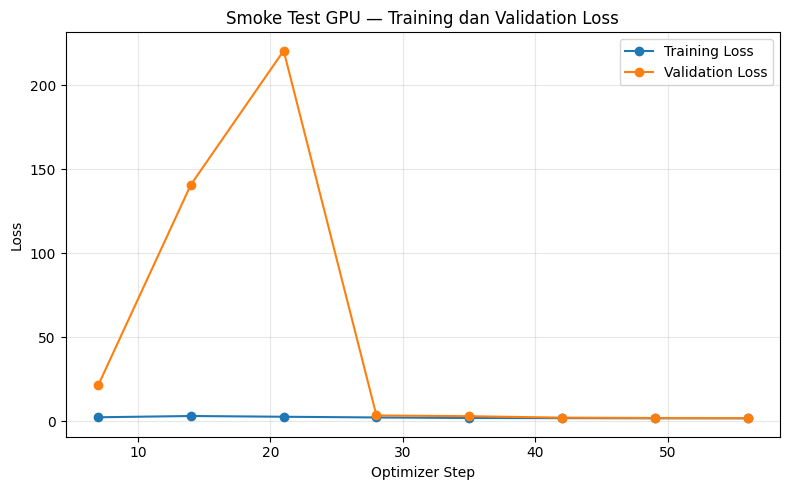

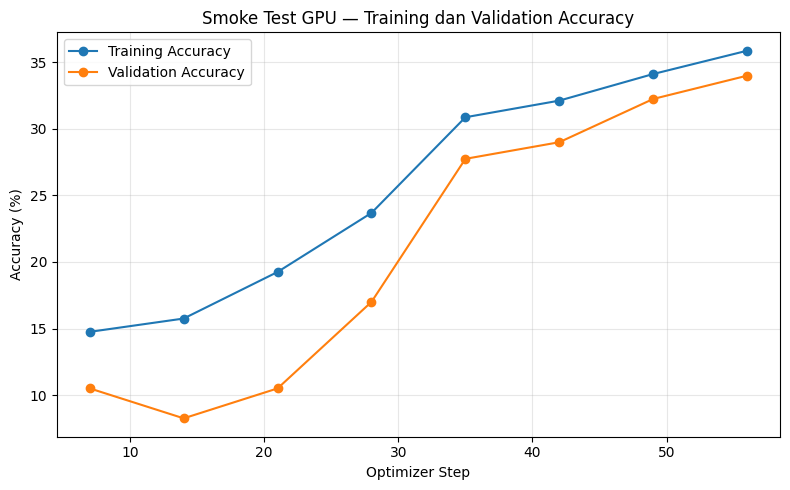

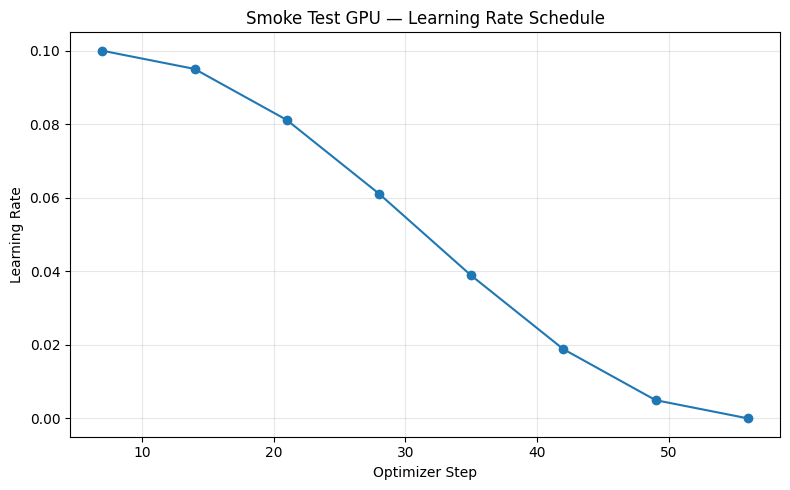

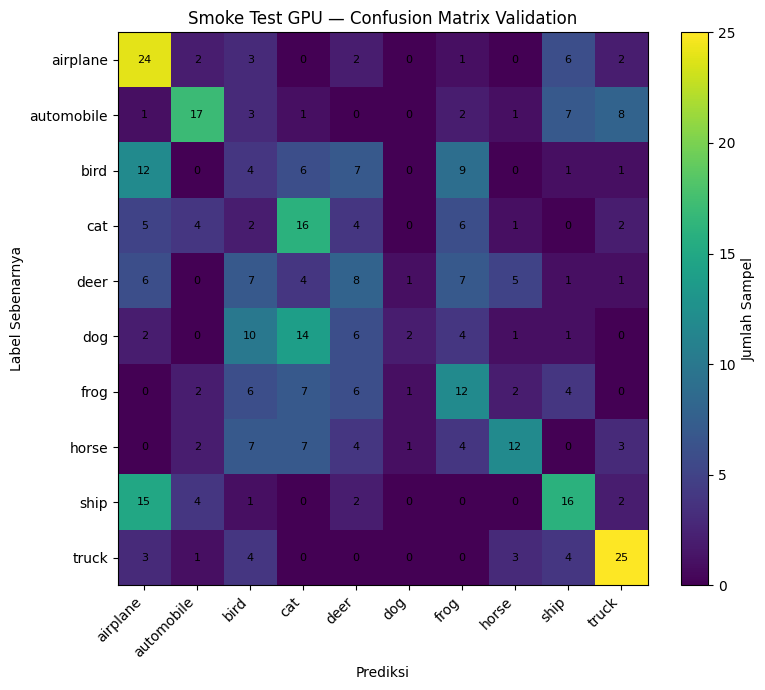

OUTPUT METRIC DAN VISUALISASI
History CSV       : /content/drive/MyDrive/skripsi_label_noise/outputs/metrics/smoke test validation/smoke_training_history.csv
Loss curve        : /content/drive/MyDrive/skripsi_label_noise/outputs/figures/smoke test validation/smoke_loss_curve.png
Accuracy curve    : /content/drive/MyDrive/skripsi_label_noise/outputs/figures/smoke test validation/smoke_accuracy_curve.png
Learning-rate     : /content/drive/MyDrive/skripsi_label_noise/outputs/figures/smoke test validation/smoke_learning_rate_curve.png
Confusion matrix  : /content/drive/MyDrive/skripsi_label_noise/outputs/figures/smoke test validation/smoke_confusion_matrix.png
Augmentation      : /content/drive/MyDrive/skripsi_label_noise/outputs/figures/smoke test validation/smoke_augmentation_comparison.png

✅ Seluruh metric dan visualisasi berhasil disimpan.


In [19]:
# ============================================================
# CELL 18 — METRICS DAN VISUALISASI
# ============================================================

from sklearn.metrics import (
    confusion_matrix
)


# ------------------------------------------------------------
# Gabungkan history sebelum dan sesudah checkpoint.
# ------------------------------------------------------------

df_history = pd.DataFrame(
    riwayat_1
    +
    riwayat_2
)


PATH_HISTORY = (
    DIR_METRIC
    / "smoke_training_history.csv"
)


df_history.to_csv(
    PATH_HISTORY,
    index=False
)


display(
    df_history
)


# ------------------------------------------------------------
# 1. Loss curve
# ------------------------------------------------------------

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    df_history[
        "global_step"
    ],
    df_history[
        "train_loss"
    ],
    marker="o",
    label="Training Loss"
)

plt.plot(
    df_history[
        "global_step"
    ],
    df_history[
        "val_loss"
    ],
    marker="o",
    label="Validation Loss"
)

plt.xlabel(
    "Optimizer Step"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "Smoke Test GPU — Training dan Validation Loss"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()


PATH_LOSS = (
    DIR_FIGURE
    / "smoke_loss_curve.png"
)


plt.savefig(
    PATH_LOSS,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 2. Accuracy curve
# ------------------------------------------------------------

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    df_history[
        "global_step"
    ],
    df_history[
        "train_accuracy"
    ] * 100,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    df_history[
        "global_step"
    ],
    df_history[
        "val_accuracy"
    ] * 100,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel(
    "Optimizer Step"
)

plt.ylabel(
    "Accuracy (%)"
)

plt.title(
    "Smoke Test GPU — Training dan Validation Accuracy"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()


PATH_ACC = (
    DIR_FIGURE
    / "smoke_accuracy_curve.png"
)


plt.savefig(
    PATH_ACC,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 3. Learning-rate curve
# ------------------------------------------------------------

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    df_history[
        "global_step"
    ],
    df_history[
        "learning_rate"
    ],
    marker="o"
)

plt.xlabel(
    "Optimizer Step"
)

plt.ylabel(
    "Learning Rate"
)

plt.title(
    "Smoke Test GPU — Learning Rate Schedule"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()


PATH_LR = (
    DIR_FIGURE
    / "smoke_learning_rate_curve.png"
)


plt.savefig(
    PATH_LR,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 4. Confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=np.arange(10)
)


plt.figure(
    figsize=(8, 7)
)

gambar_cm = plt.imshow(
    cm,
    aspect="auto"
)

plt.colorbar(
    gambar_cm,
    label="Jumlah Sampel"
)

plt.xticks(
    range(10),
    cifar_train_raw.classes,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(10),
    cifar_train_raw.classes
)

plt.xlabel(
    "Prediksi"
)

plt.ylabel(
    "Label Sebenarnya"
)

plt.title(
    "Smoke Test GPU — Confusion Matrix Validation"
)


for i in range(10):

    for j in range(10):

        plt.text(
            j,
            i,
            str(
                cm[
                    i,
                    j
                ]
            ),
            ha="center",
            va="center",
            fontsize=8
        )


plt.tight_layout()


PATH_CM = (
    DIR_FIGURE
    / "smoke_confusion_matrix.png"
)


plt.savefig(
    PATH_CM,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


print("=" * 70)
print("OUTPUT METRIC DAN VISUALISASI")
print("=" * 70)

print(
    "History CSV       :",
    PATH_HISTORY
)

print(
    "Loss curve        :",
    PATH_LOSS
)

print(
    "Accuracy curve    :",
    PATH_ACC
)

print(
    "Learning-rate     :",
    PATH_LR
)

print(
    "Confusion matrix  :",
    PATH_CM
)

print(
    "Augmentation      :",
    PATH_AUG
)

print()
print(
    "✅ Seluruh metric dan visualisasi berhasil disimpan."
)

# CELL 19 — Final checkpoint + metadata

In [21]:
# ============================================================
# CELL 19 — FINAL CHECKPOINT DAN RUN METADATA
# ============================================================

import platform
import torchvision
from datetime import datetime


LOCAL_FINAL_CHECKPOINT = Path(
    "/content/"
    "smoke_gpu_final.pt"
)


DRIVE_FINAL_CHECKPOINT = (
    DIR_CHECKPOINT
    / "smoke_resnet18_gpu_final.pt"
)


# ------------------------------------------------------------
# Final checkpoint.
# ------------------------------------------------------------

simpan_checkpoint(
    lokasi=LOCAL_FINAL_CHECKPOINT,
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    scaler=scaler,
    global_step=step_akhir,
    generator_train=generator_train_resume,
    config=SMOKE_CONFIG,
)


shutil.copy2(
    LOCAL_FINAL_CHECKPOINT,
    DRIVE_FINAL_CHECKPOINT
)


assert (
    DRIVE_FINAL_CHECKPOINT.exists()
)


FINAL_CHECKPOINT_SHA256 = hitung_sha256(
    DRIVE_FINAL_CHECKPOINT
)


RUN_ID = (
    "smoke__c10_clean__"
    "r18__gpu__seed017"
)


run_metadata = {

    "run_id":
        RUN_ID,

    "fase":
        "Smoke Test Validation",

    "status":
        "FINISHED",

    "timestamp":
        datetime.now().isoformat(),

    "git_commit":
        GIT_COMMIT,

    "python_version":
        platform.python_version(),

    "torch_version":
        torch.__version__,

    "torchvision_version":
        torchvision.__version__,

    "cuda_version":
        torch.version.cuda,

    "gpu":
        torch.cuda.get_device_name(0),

    "device":
        str(device),

    "amp":
        True,

    "deterministic":
        True,

    "dataset":
        "CIFAR-10 clean",

    "official_test_used":
        False,

    "subset_seed":
        SUBSET_SEED,

    "training_seed":
        TRAINING_SEED,

    "subset_total":
        2000,

    "train_samples":
        1600,

    "validation_samples":
        400,

    "model":
        "resnet18",

    "batch_size":
        BATCH_SIZE,

    "optimizer":
        "SGD",

    "learning_rate":
        SMOKE_CONFIG[
            "learning_rate"
        ],

    "momentum":
        SMOKE_CONFIG[
            "momentum"
        ],

    "weight_decay":
        SMOKE_CONFIG[
            "weight_decay"
        ],

    "scheduler":
        SMOKE_CONFIG[
            "scheduler"
        ],

    "warmup_steps":
        WARMUP_STEPS,

    "checkpoint_step":
        STEP_CHECKPOINT,

    "total_optimizer_steps":
        step_akhir,

    "checkpoint_resume_verified":
        True,

    "runtime_seconds":
        float(
            WAKTU_TOTAL
        ),

    "peak_allocated_vram_gb":
        float(
            PEAK_ALLOCATED_GB
        ),

    "peak_reserved_vram_gb":
        float(
            PEAK_RESERVED_GB
        ),

    "final_val_loss":
        float(
            final_metric[
                "loss"
            ]
        ),

    "final_val_accuracy":
        float(
            final_metric[
                "accuracy"
            ]
        ),

    "final_val_macro_f1":
        float(
            final_metric[
                "macro_f1"
            ]
        ),

    "checkpoint_sha256":
        FINAL_CHECKPOINT_SHA256,

    "notes":
        (
            "Smoke test pipeline GPU. "
            "Bukan hasil main experiment."
        ),
}


PATH_METADATA = (
    DIR_METADATA
    / f"{RUN_ID}.json"
)


with open(
    PATH_METADATA,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        run_metadata,
        file,
        indent=4
    )


print("=" * 70)
print("RUN METADATA FINAL")
print("=" * 70)

print(
    "Run ID              :",
    RUN_ID
)

print(
    "Final checkpoint    :",
    DRIVE_FINAL_CHECKPOINT
)

print(
    "Checkpoint SHA-256  :",
    FINAL_CHECKPOINT_SHA256
)

print(
    "Metadata            :",
    PATH_METADATA
)

print()
print(
    "✅ Final checkpoint dan metadata tersimpan."
)

RUN METADATA FINAL
Run ID              : smoke__c10_clean__r18__gpu__seed017
Final checkpoint    : /content/drive/MyDrive/skripsi_label_noise/outputs/checkpoints/smoke test validation/smoke_resnet18_gpu_final.pt
Checkpoint SHA-256  : 4bd17888857e0344f988bae8d54551f47ce795c75465a0a64f0c246590dc02cb
Metadata            : /content/drive/MyDrive/skripsi_label_noise/outputs/run_metadata/smoke test validation/smoke__c10_clean__r18__gpu__seed017.json

✅ Final checkpoint dan metadata tersimpan.


# CELL 20 — Gate validasi akhir

In [22]:
# ============================================================
# CELL 20 — VALIDASI AKHIR
# ============================================================

semua_metric_finite = all(
    np.isfinite(
        df_history[
            kolom
        ].values
    ).all()

    for kolom in [
        "train_loss",
        "train_accuracy",
        "val_loss",
        "val_accuracy",
        "val_macro_f1",
        "learning_rate",
    ]
)


checks = {

    "GPU CUDA aktif":
        torch.cuda.is_available(),

    "device model adalah CUDA":
        (
            next(
                model.parameters()
            ).device.type
            ==
            "cuda"
        ),

    "AMP aktif":
        AMP_AKTIF,

    "subset smoke = 2.000":
        len(
            indeks_smoke
        )
        ==
        2000,

    "training = 1.600":
        len(
            indeks_train
        )
        ==
        1600,

    "validation = 400":
        len(
            indeks_val
        )
        ==
        400,

    "train-validation tidak overlap":
        len(
            overlap
        )
        ==
        0,

    "split stratified":
        (
            np.all(
                df_distribusi[
                    "training"
                ].values
                ==
                160
            )
            and
            np.all(
                df_distribusi[
                    "validation"
                ].values
                ==
                40
            )
        ),

    "official test tidak digunakan":
        (
            run_metadata[
                "official_test_used"
            ]
            is False
        ),

    "checkpoint tahap 1 tersedia":
        DRIVE_CHECKPOINT.exists(),

    "checkpoint integrity lolos":
        (
            hash_lokal
            ==
            hash_drive
        ),

    "checkpoint resume berhasil":
        (
            STEP_RESUME
            ==
            STEP_CHECKPOINT
        ),

    "training mencapai fixed-step target":
        (
            step_akhir
            ==
            TOTAL_STEP
        ),

    "metric seluruhnya finite":
        semua_metric_finite,

    "peak allocated VRAM > 0":
        (
            PEAK_ALLOCATED_GB
            >
            0
        ),

    "peak reserved VRAM > 0":
        (
            PEAK_RESERVED_GB
            >
            0
        ),

    "history CSV tersedia":
        PATH_HISTORY.exists(),

    "augmentation figure tersedia":
        PATH_AUG.exists(),

    "loss curve tersedia":
        PATH_LOSS.exists(),

    "accuracy curve tersedia":
        PATH_ACC.exists(),

    "learning-rate curve tersedia":
        PATH_LR.exists(),

    "confusion matrix tersedia":
        PATH_CM.exists(),

    "final checkpoint tersedia":
        DRIVE_FINAL_CHECKPOINT.exists(),

    "metadata JSON tersedia":
        PATH_METADATA.exists(),
}


print("=" * 70)
print("LAPORAN VALIDASI GPU")
print("=" * 70)


SEMUA_LULUS = True


for nama_check, status in (
    checks.items()
):

    simbol = (
        "✅"
        if status
        else "❌"
    )

    print(
        f"{simbol} {nama_check}"
    )

    if not status:

        SEMUA_LULUS = False


print()


if SEMUA_LULUS:

    print("=" * 70)
    print(
        "SMOKE TEST GPU BERHASIL"
    )
    print("=" * 70)

    print()
    print(
        "Pipeline training GPU, AMP, fixed-step, "
        "checkpoint, resume, evaluasi, logging, "
        "resource monitoring, dan visualisasi "
        "telah lolos validasi."
    )

    print()
    print(
        "Metric smoke test TIDAK digunakan "
        "sebagai hasil eksperimen skripsi."
    )

else:

    raise RuntimeError(
        "belum lolos seluruh validasi. "
        "Jangan lanjut ke pilot."
    )

LAPORAN VALIDASI GPU
✅ GPU CUDA aktif
✅ device model adalah CUDA
✅ AMP aktif
✅ subset smoke = 2.000
✅ training = 1.600
✅ validation = 400
✅ train-validation tidak overlap
✅ split stratified
✅ official test tidak digunakan
✅ checkpoint tahap 1 tersedia
✅ checkpoint integrity lolos
✅ checkpoint resume berhasil
✅ training mencapai fixed-step target
✅ metric seluruhnya finite
✅ peak allocated VRAM > 0
✅ peak reserved VRAM > 0
✅ history CSV tersedia
✅ augmentation figure tersedia
✅ loss curve tersedia
✅ accuracy curve tersedia
✅ learning-rate curve tersedia
✅ confusion matrix tersedia
✅ final checkpoint tersedia
✅ metadata JSON tersedia

SMOKE TEST GPU BERHASIL

Pipeline training GPU, AMP, fixed-step, checkpoint, resume, evaluasi, logging, resource monitoring, dan visualisasi telah lolos validasi.

Metric smoke test TIDAK digunakan sebagai hasil eksperimen skripsi.


# COMMIT & PUSH

In [24]:
# ============================================================
# PERBAIKAN IDENTITAS GIT + COMMIT
# ============================================================

import subprocess


REPO_DIR = "/content/label-noise-thesis"


def git_run(command):

    hasil = subprocess.run(
        command,
        cwd=REPO_DIR,
        capture_output=True,
        text=True
    )

    print("\n$", " ".join(command))

    if hasil.stdout:
        print(hasil.stdout)

    if hasil.stderr:
        print(hasil.stderr)

    return hasil



# ============================================================
# 1. SET IDENTITAS GIT
# ============================================================

print("=" * 70)
print("KONFIGURASI IDENTITAS GIT")
print("=" * 70)


git_run(
    [
        "git",
        "config",
        "--global",
        "user.name",
        "luthfiaw13"
    ]
)


git_run(
    [
        "git",
        "config",
        "--global",
        "user.email",
        "luthfiaw13@users.noreply.github.com"
    ]
)


print("✅ Identitas Git selesai.")



# ============================================================
# 2. STAGING FILE
# ============================================================

print("=" * 70)
print("GIT ADD")
print("=" * 70)


git_run(
    [
        "git",
        "add",
        "src/training/checkpoint.py"
    ]
)


# ============================================================
# 3. CEK PERUBAHAN & COMMIT
# ============================================================

print("=" * 70)
print("GIT COMMIT")
print("=" * 70)

status = git_run(["git", "status", "--porcelain"])

if not status.stdout.strip():
    print("\nℹ️ Tidak ada perubahan untuk dicommit.")
else:
    commit = git_run(
        [
            "git",
            "commit",
            "-m",
            "Finalize GPU smoke test pipeline and checkpoint reproducibility"
        ]
    )

    if commit.returncode != 0:
        print("❌ Commit gagal.")
    else:
        print("✅ Commit berhasil.")

        # ============================================================
        # 4. PUSH (Hanya jika commit berhasil)
        # ============================================================

        print("=" * 70)
        print("GIT PUSH")
        print("=" * 70)

        push = git_run(
            [
                "git",
                "push",
                "origin",
                "main"
            ]
        )

        if push.returncode != 0:
            print("❌ Push gagal.")
        else:
            print("✅ Push berhasil.")



# ============================================================
# 5. FINAL STATUS
# ============================================================

print("=" * 70)
print("STATUS AKHIR")
print("=" * 70)


git_run(
    [
        "git",
        "status"
    ]
)

print()
print("✅ PROSES GIT SELESAI.")

KONFIGURASI IDENTITAS GIT

$ git config --global user.name luthfiaw13

$ git config --global user.email luthfiaw13@users.noreply.github.com
✅ Identitas Git selesai.
GIT ADD

$ git add src/training/checkpoint.py
GIT COMMIT

$ git status --porcelain

ℹ️ Tidak ada perubahan untuk dicommit.
STATUS AKHIR

$ git status
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


✅ PROSES GIT SELESAI.
